# 🚢 Titanic Survival Prediction

**Author:** Pham Duy Truong  
**Dataset:** Titanic (891 passengers, 12 features)  
**Model:** Random Forest Classifier  

**Modules covered:**
1. Dataset Summary & EDA & Visualization
2. Data Cleansing
3. Feature Engineering & Encoding
4. Feature Selection & Scaling
5. Handling Imbalanced Data (SMOTE)
6. Model Building & Prediction
7. Hyperparameter Tuning
8. Conclusion

---
## 1. Import Libraries & Dependencies

In [ ]:
#pip install pandas matplotlib seaborn datetime scikit-learn imbalanced-learn

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

---
## 2. Load & Summarize the Dataset

Load the Titanic CSV and explore its structure: shape, data types, statistics, and missing values.

In [ ]:
path = ''
df = pd.read_csv('titanic.csv')

In [45]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

In [46]:
df.shape

(891, 12)

In [47]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [48]:
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [49]:
def missing_cols(df):
    total = 0
    for col in df.columns:
        missing_vals = df[col].isnull().sum()
        # mean = sum / total
        pct = df[col].isnull().mean() * 100 
        if missing_vals != 0:
          print('{} => {} [{}%]'.format(col, df[col].isnull().sum(), round(pct, 2)))
        total += missing_vals
    
    if total == 0:
        print("no missing values left 🎉 ")

def get_memory(df):
  """ prints out size of data frame in MB """
  print(f"{round(df.memory_usage().sum() / 1000000, 2)} MB")

In [50]:
missing_cols(df)
get_memory(df)

Age => 177 [19.87%]
Cabin => 687 [77.1%]
Embarked => 2 [0.22%]
0.09 MB


---
## 3. Exploratory Data Analysis (EDA) & Visualization

Understand patterns, distributions, and relationships in the data before modelling.

### 3.1 Target Distribution (Survived)

Text(0.5, 1.0, 'Survival Distribution (0 = no, 1 = yes)')

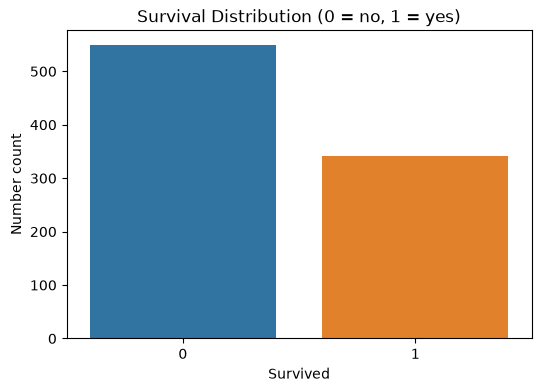

In [51]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
sns.countplot(x = 'Survived', hue = 'Survived', data = df, ax = ax, legend = False)
ax.set_ylabel('Number count') 
ax.set_title('Survival Distribution (0 = no, 1 = yes)')

### 3.2 Survival by Categorical Features (Sex, Age, Embarked)

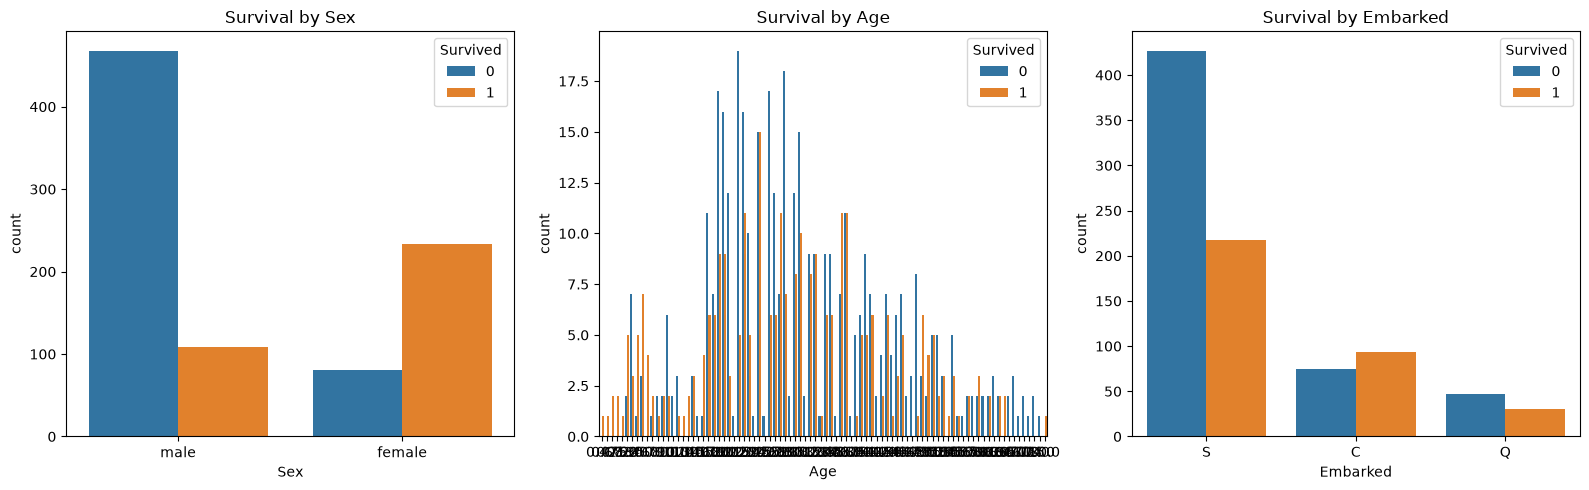

In [52]:
features = ['Sex', 'Age', 'Embarked']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, feature in enumerate(features):
    sns.countplot(x=feature, hue='Survived', data=df, ax=axes[i])
    axes[i].set_title(f'Survival by {feature}')

plt.tight_layout()
plt.show()

### 3.3 Age Distribution by Survival

<Axes: xlabel='Age', ylabel='Count'>

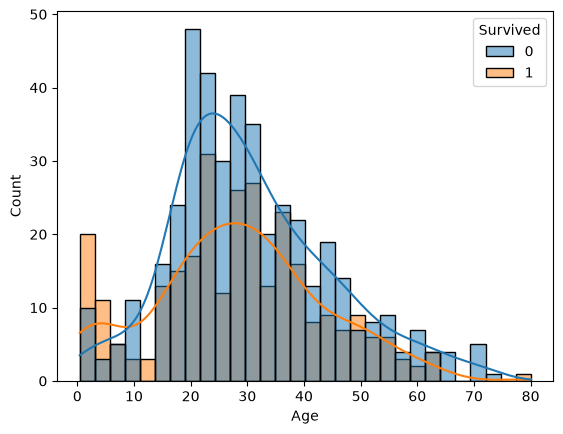

In [53]:
sns.histplot(data=df, x='Age', hue='Survived', kde=True, bins=30)

### 3.4 Fare Distribution by Pclass & Survival

<Axes: xlabel='Pclass', ylabel='Fare'>

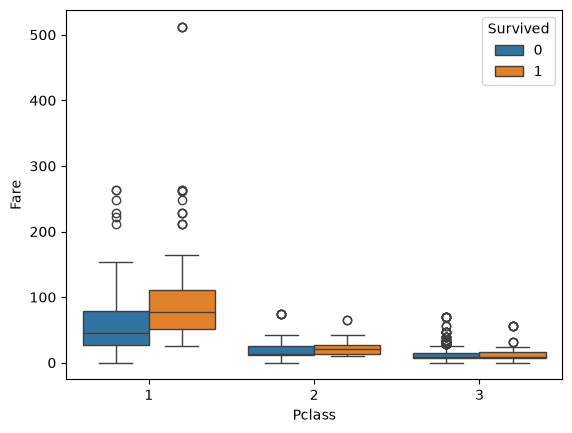

In [54]:
sns.boxplot(x='Pclass', y='Fare', hue='Survived', data=df)

### 3.5 Correlation Heatmap

<Axes: >

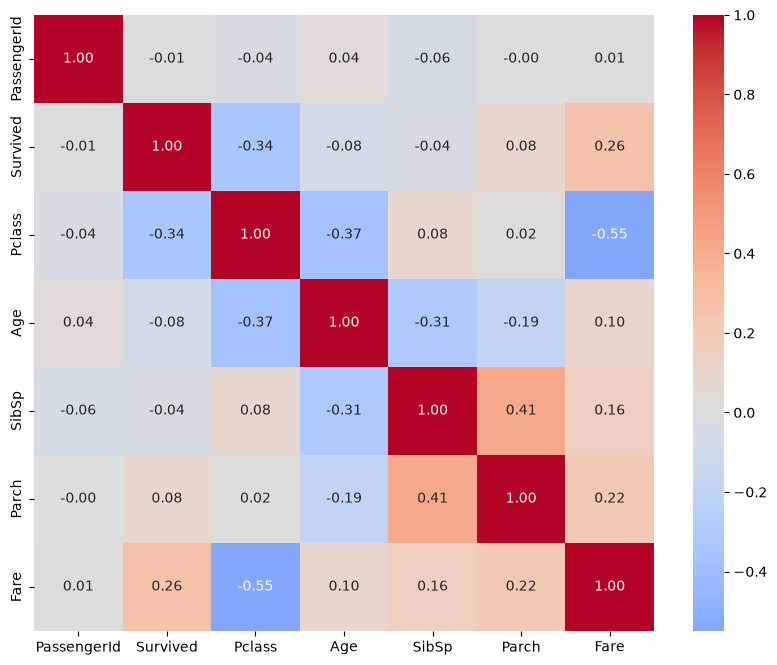

In [55]:
corr = df.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')

---
## 4. Data Cleansing

**Issues to fix:**
- `Age`: ~20% missing → impute using median grouped by extracted Title
- `Cabin`: 77% missing → convert to binary `HasCabin` feature, then drop
- `Embarked`: 2 nulls → fill with mode ('S')
- Drop columns not useful for prediction: `PassengerId`, `Name`, `Ticket`
- Extract `Title` from `Name` before dropping it

### 4.1 Handle Age — Impute by Title Group

In [57]:
#imputer = KNNImputer(n_neighbors=5)
#df[['Age', 'Pclass', 'SibSp', 'Parch', 'Fare']] = imputer.fit_transform(df[['Age', 'Pclass', 'SibSp', 'Parch', 'Fare']])

In [58]:
#There is nearly 20% of missing age values so we need to fill them
#Age can be predicted by name title
df['Title'] = df['Name'].str.extract(r',\s*([^.]*)\.')
print(df['Title'].value_counts())

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Major             2
Mlle              2
Col               2
Don               1
Mme               1
Ms                1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64


### 4.2 Feature Engineering — Extract Title from Name

In [59]:
title_map = {
    'Mlle': 'Miss',
    'Ms': 'Miss',
    'Mme': 'Mrs',
    'Lady': 'Rare', 
    'Countess': 'Rare', 
    'Capt': 'Rare', 
    'Col': 'Rare',
    'Don': 'Rare',
    'Dr': 'Rare',
    'Major': 'Rare',
    'Rev': 'Rare',
    'Sir': 'Rare',
    'Jonkheer': 'Rare',
    'Dona': 'Rare',
    'the Countess': 'Rare'
}
df['Title'] = df['Title'].replace(title_map)
print(df['Title'].value_counts())

Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64


### 4.3 Verify Age Imputation

In [62]:
print(df['Age'].isnull().sum()) 

0


In [63]:
df.groupby('Title')['Age'].mean()

Title
Master     4.620950
Miss      21.342432
Mr        32.485687
Mrs       35.747619
Rare      45.652174
Name: Age, dtype: float64

### 4.4 Handle Embarked — Fill Missing with Mode

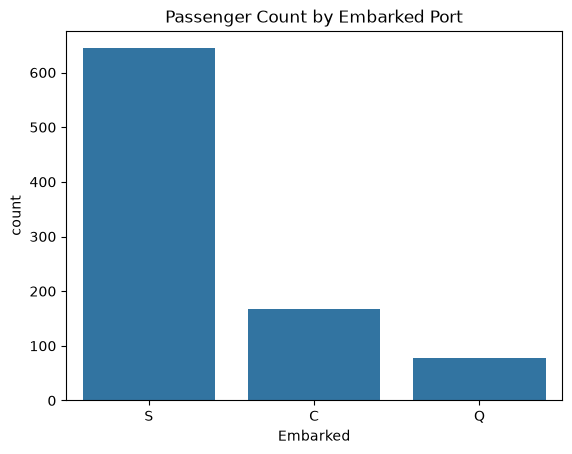

In [65]:
sns.countplot(x='Embarked', data=df, order=df['Embarked'].value_counts().index)
plt.title('Passenger Count by Embarked Port')
plt.show()

In [66]:
# Check for missing embarked value
print(df['Embarked'].isnull().sum())

2


In [67]:
#Since S is the most value, we can just fill those 2 missing values with it
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0]) 
print(df['Embarked'].isnull().sum())

0


### 4.5 Drop Unnecessary Columns & Create HasCabin

In [68]:
df =  df.drop(columns=['PassengerId', 'Ticket', 'Name']).copy()
df.head(10)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Title
0,0,3,male,22.0,1,0,7.2500,NaN,S,Mr
1,1,1,female,38.0,1,0,71.2833,C85,C,Mrs
2,1,3,female,26.0,0,0,7.9250,NaN,S,Miss
3,1,1,female,35.0,1,0,53.1000,C123,S,Mrs
4,0,3,male,35.0,0,0,8.0500,NaN,S,Mr
5,0,3,male,26.2,0,0,8.4583,NaN,Q,Mr
6,0,1,male,54.0,0,0,51.8625,E46,S,Mr
7,0,3,male,2.0,3,1,21.0750,NaN,S,Master
8,1,3,female,27.0,0,2,11.1333,NaN,S,Mrs
9,1,2,female,14.0,1,0,30.0708,NaN,C,Mrs


In [69]:
df['HasCabin'] = df['Cabin'].notna().astype(int)
df = df.drop(columns=['Cabin']).copy()

### 4.6 Verify — No Missing Values Left

In [70]:
df.head(10)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,HasCabin
0,0,3,male,22.0,1,0,7.2500,S,Mr,0
1,1,1,female,38.0,1,0,71.2833,C,Mrs,1
2,1,3,female,26.0,0,0,7.9250,S,Miss,0
3,1,1,female,35.0,1,0,53.1000,S,Mrs,1
4,0,3,male,35.0,0,0,8.0500,S,Mr,0
5,0,3,male,26.2,0,0,8.4583,Q,Mr,0
6,0,1,male,54.0,0,0,51.8625,S,Mr,1
7,0,3,male,2.0,3,1,21.0750,S,Master,0
8,1,3,female,27.0,0,2,11.1333,S,Mrs,0
9,1,2,female,14.0,1,0,30.0708,C,Mrs,0


In [71]:
missing_cols(df)

no missing values left 🎉 


---
## 5. Feature Encoding

Convert categorical columns to numerical:
- `Sex` → Label Encoding (binary: female=0, male=1)
- `Embarked` → One-Hot Encoding (nominal: S, C, Q)
- `Title` → One-Hot Encoding (nominal: Mr, Mrs, Miss, etc.)

### 5.1 Label Encode `Sex`

In [72]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])  # female=0, male=1

### 5.2 One-Hot Encode `Embarked`

In [73]:
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

In [74]:
print(df.dtypes)

Survived        int64
Pclass          int64
Sex             int64
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Title             str
HasCabin        int64
Embarked_Q       bool
Embarked_S       bool
dtype: object


### 5.3 One-Hot Encode `Title`

In [75]:
df = pd.get_dummies(df, columns=['Title'], drop_first=True)

In [76]:
print(df.dtypes)

Survived        int64
Pclass          int64
Sex             int64
Age           float64
SibSp           int64
Parch           int64
Fare          float64
HasCabin        int64
Embarked_Q       bool
Embarked_S       bool
Title_Miss       bool
Title_Mr         bool
Title_Mrs        bool
Title_Rare       bool
dtype: object


In [77]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,HasCabin,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,0,3,1,22.0,1,0,7.2500,0,False,True,False,True,False,False
1,1,1,0,38.0,1,0,71.2833,1,False,False,False,False,True,False
2,1,3,0,26.0,0,0,7.9250,0,False,True,True,False,False,False
3,1,1,0,35.0,1,0,53.1000,1,False,True,False,False,True,False
4,0,3,1,35.0,0,0,8.0500,0,False,True,False,True,False,False


---
## 6. Feature Selection & Scaling

- Use `SelectKBest` with chi-squared test to rank features
- Scale numerical features (`Age`, `Fare`, `SibSp`, `Parch`) with `StandardScaler`

### 6.1 Separate Features (X) and Target (y) + Feature Selection

In [78]:
from sklearn.feature_selection import SelectKBest, chi2

X = df.drop('Survived', axis=1)
y = df['Survived']

selector = SelectKBest(score_func=chi2, k='all')  # use f_classif if features have negatives
selector.fit(X, y)
scores = pd.DataFrame({'Feature': X.columns, 'Score': selector.scores_})
print(scores.sort_values('Score', ascending=False))

       Feature        Score
5         Fare  4518.319091
10    Title_Mr   112.805785
1          Sex    92.702447
11   Title_Mrs    89.474177
9   Title_Miss    79.531749
6     HasCabin    68.997412
0       Pclass    30.873699
2          Age    25.152233
4        Parch    10.097499
8   Embarked_S     5.489205
3        SibSp     2.581865
12  Title_Rare     0.126121
7   Embarked_Q     0.010847


### 6.2 Train-Test Split (Stratified)

In [112]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=67, stratify=y)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Train target distribution:\n{y_train.value_counts(normalize=True)}')

Train: (712, 13), Test: (179, 13)
Train target distribution:
Survived
0    0.616573
1    0.383427
Name: proportion, dtype: float64


### 6.3 Scale Numerical Features

In [86]:
numerical_cols = ['Age', 'Fare', 'SibSp', 'Parch']  # adjust based on your features
scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])
X_train.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,HasCabin,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
692,3,1,0.115570,-0.465084,-0.466183,0.513812,0,False,True,False,True,False,False
481,2,1,0.579297,-0.465084,-0.466183,-0.662563,0,False,True,False,True,False,False
527,1,1,-0.290191,-0.465084,-0.466183,3.955399,1,False,True,False,True,False,False
855,3,0,-0.855359,-0.465084,0.727782,-0.467874,0,False,True,False,False,True,False
801,2,0,0.086587,0.478335,0.727782,-0.115977,0,False,True,False,False,True,False


---
## 7. Handling Imbalanced Data

The dataset is imbalanced (~62% died vs ~38% survived).  
Apply **SMOTE** (Synthetic Minority Over-sampling) on the **training data only** to balance classes.

In [89]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
print(f'Before SMOTE: {y_train.value_counts().to_dict()}')
print(f'After SMOTE:  {pd.Series(y_train_resampled).value_counts().to_dict()}')

Before SMOTE: {0: 439, 1: 273}
After SMOTE:  {1: 439, 0: 439}


---
## 8. Build Random Forest Model & Evaluate

Train a Random Forest classifier on SMOTE-resampled data, then evaluate on original test set.

### 8.1 Train & Predict

In [166]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train_resampled, y_train_resampled)

y_pred = rf.predict(X_test)
y_pred_proba = rf.predict_proba(X_test)[:, 1]

### 8.2 Classification Report & ROC-AUC

In [167]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
print('Classification Report:')
print(classification_report(y_test, y_pred))

print(f'ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}')

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.85      0.82       110
           1       0.74      0.65      0.69        69

    accuracy                           0.78       179
   macro avg       0.77      0.75      0.76       179
weighted avg       0.77      0.78      0.77       179

ROC-AUC Score: 0.8199


### 8.3 Confusion Matrix

Text(0.5, 1.0, 'Confusion Matrix')

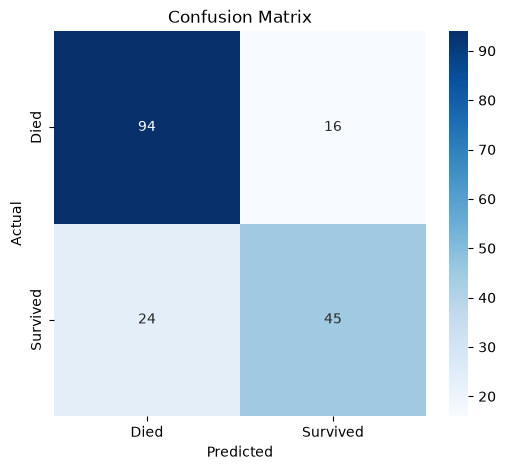

In [168]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Died', 'Survived'], yticklabels=['Died', 'Survived'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

### 8.4 ROC Curve

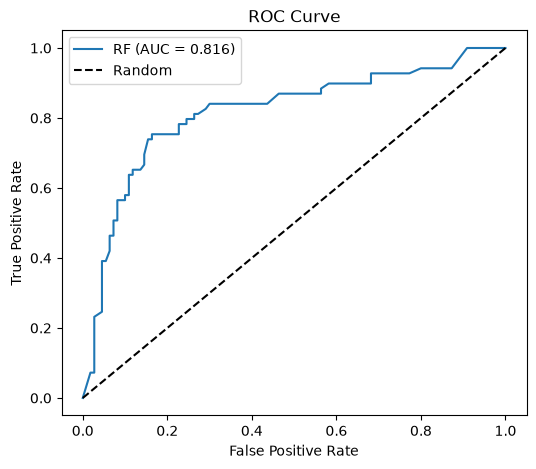

In [102]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'RF (AUC = {roc_auc_score(y_test, y_pred_proba):.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

### 8.5 Feature Importance

Text(0.5, 0, 'Importance')

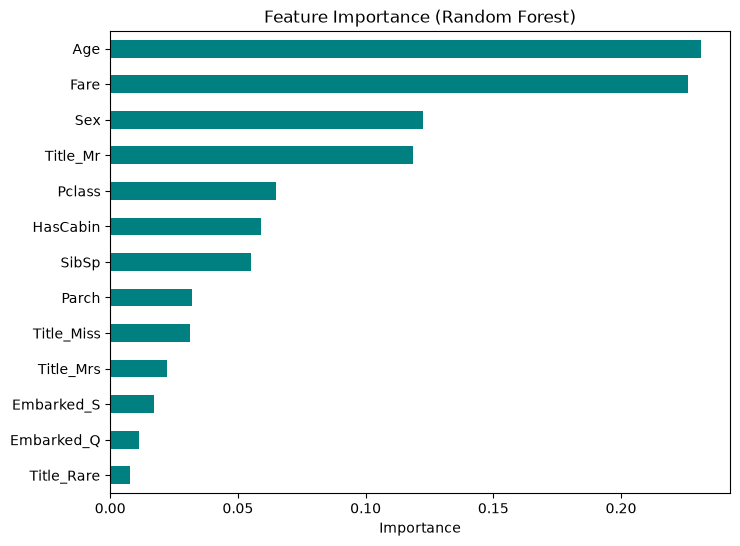

In [103]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values(ascending=True).plot(kind='barh', figsize=(8, 6), color='teal')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance')

In [104]:
from sklearn.inspection import permutation_importance

result = permutation_importance(rf, X_test, y_test, n_repeats=10, random_state=42)
perm_importances = pd.Series(result.importances_mean, index=X_test.columns).sort_values(ascending=False)
print(perm_importances)

Age           0.042458
Title_Mr      0.041341
Sex           0.030168
Fare          0.027374
Pclass        0.016201
HasCabin      0.012291
SibSp         0.003352
Title_Rare    0.000000
Embarked_Q   -0.000559
Title_Miss   -0.007263
Title_Mrs    -0.008939
Parch        -0.012849
Embarked_S   -0.016201
dtype: float64


---
## 9. Hyperparameter Tuning

Use `GridSearchCV` with `StratifiedKFold` to find optimal Random Forest parameters.

In [111]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': [None, 'balanced']
}

In [170]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=cv,
    scoring='roc_auc',  # or 'f1', 'accuracy'
    n_jobs=-1,
    verbose=1
)

# Fit on resampled training data
grid_search.fit(X_train_resampled, y_train_resampled)


Fitting 5 folds for each of 216 candidates, totalling 1080 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': [None, 'balanced'], 'max_depth': [None, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple

---
## 10. Conclusion

**TODO:** Write a brief summary covering:
- What data quality issues were found and how they were fixed
- Which features were most important for prediction
- How SMOTE affected model performance on the minority class
- How much hyperparameter tuning improved the model
- Final model accuracy, precision, recall, and AUC score

In [ ]:
# Your conclusion here
